In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datetime import datetime

from curve_fitting import *
from plotting_utils import *
from read_hatch import *

savefig_settings = {'bbox_inches': 'tight', 'facecolor': 'w', 'dpi': 300}
save_fig = False

# Rerun timeseries stats

In [2]:
from main import run_all_fits

rerun_ts_stats = False

if rerun_ts_stats:
    run_all_fits(stats_only=True)

In [3]:
# import data
df = read_hatch('data/HATCH_v1.5_clean.csv', drop_const=False)
len(df)

Removed timeseries with less than 10 data points: 1380


5547

In [4]:
df.columns[:8]

Index(['Spatial Scale', 'Region', 'Country Name', 'Technology Name', 'Metric',
       'Unit', 'Data Source', 'Variable'],
      dtype='object')

In [5]:
df['Metric'].unique()

array(['Annual Production', 'Cumulative Length', 'Total Number',
       'Cumulative Total Capacity', 'Cumulative total capacity',
       'Total Length', 'Annual production', 'Share of Households',
       'Net Total Capacity', 'Installed Capacity', 'Share of Population',
       'Computing Capacity', 'Share of Market', 'Cumulative Rated Power',
       'Cumulative Rated Capacity', 'Cumulative Acreage',
       'Installed electricity capacity', 'Share of Boilers'], dtype=object)

In [6]:
# check timeseries data

#df.loc['Railroad_Cumulative Length_KH'].iloc[8:].dropna()

# Run curve_fitting on all timeseries

In [ ]:
# note: for reponse 'infodict' to be recorded in fitting procedure, set verbosity > 2

test = True

start_time = datetime.now()
# suppress overflow warnings
np.seterr(over='ignore', under='ignore')

all_results = []

if test:
    loop_ids = np.arange(0, 10)
else:
    loop_ids = np.arange(0, len(df.index))

print(f"{start_time} - Start running loop over all timeseries")

for i in loop_ids:
    sl = df.iloc[i, 9:].transpose().dropna()
    tech_name = sl.name
    technology = df['Technology Name'].iloc[i]
    print(f"{datetime.now() - start_time} - Fitting {i}: {tech_name}")

    years = sl.index.to_numpy(dtype='float')

    if years.min() < 0 or years.max() > 2050:
        print("Warning: Time is not in years:", years)
        continue

    values = sl.to_numpy(dtype='float')

    rs = make_curve_fits(years, values, tech_name=tech_name, verbosity=0)
    for r in rs: r['Technology Name'] = technology

    all_results += rs

today = datetime.today().strftime('%Y-%m-%d')

# store fit parameters
fit_params = pd.DataFrame(all_results)
if not test:
    fit_params.to_csv(f"./results/fitting_parameters_all_{today}.csv")

print("Loop run finished.")

2025-01-31 17:00:17.434542 - Start running loop over all timeseries
0:00:00.000870 - Fitting 0: Sugar Output_Annual Production_JM
0:00:00.301425 - Fitting 1: Sugar Output_Annual Production_BB
0:00:00.428897 - Fitting 2: Sugar Output_Annual Production_CU
0:00:00.568781 - Fitting 3: Beer_Annual Production_GB
0:00:00.851671 - Fitting 4: Sugar Output_Annual Production_MU
0:00:01.425373 - Fitting 5: Railroad_Cumulative Length_NO
0:00:01.713688 - Fitting 6: Railroad_Cumulative Length_FR
0:00:01.972202 - Fitting 7: Railroad_Cumulative Length_FI
0:00:02.264797 - Fitting 8: Railroad_Cumulative Length_SE
0:00:02.517570 - Fitting 9: Railroad_Cumulative Length_DK
Loop run finished.


In [4]:
print(len(fit_params))

90


Time for computation: ~ 1.2 h

In [27]:
fit_params['fit_success'].value_counts()

fit_success
True     49867
False       56
Name: count, dtype: int64

In [28]:
# check that all have a fit message
fit_params['fit_message'].isna().sum()

56

In [29]:
fit_params['fit_message'].value_counts()

fit_message
`ftol` termination condition is satisfied.                                                                                                                                     35170
`xtol` termination condition is satisfied.                                                                                                                                      5477
Both actual and predicted relative reductions in the sum of squares\n  are at most 0.000000                                                                                     4826
Both `ftol` and `xtol` termination conditions are satisfied.                                                                                                                    2000
`gtol` termination condition is satisfied.                                                                                                                                      1673
Both actual and predicted relative reductions in the sum of squares\n  are at most 

In [30]:
fit_params['int_flat'].unique()

array([ 2.,  3.,  1.,  4., nan])

In [31]:
#pd.json_normalize(fit_params['infodict'])

In [32]:
fit_params['technology'].nunique()

5547

## Look at results

In [33]:
save_fig = False
sample='all'

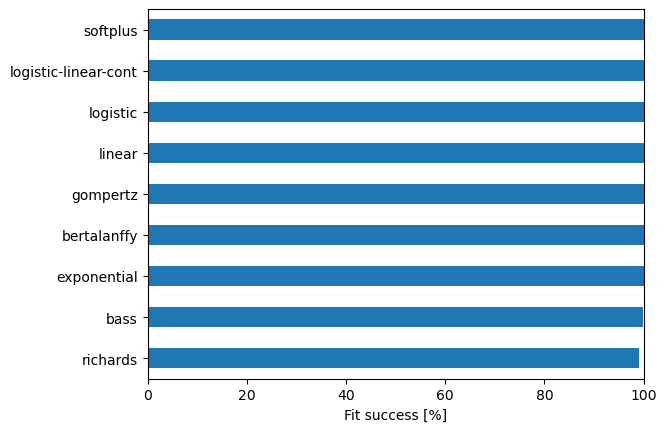

In [34]:
fit_success = 100 * fit_params.groupby('functional_form')['fit_success'].mean()
fit_success.sort_values().plot.barh()
plt.xlabel('Fit success [%]')
plt.ylabel('')
plt.xlim([0, 100])

if save_fig:
    plt.savefig(f'figures/{sample}_{today}_fit_success.png', **savefig_settings)

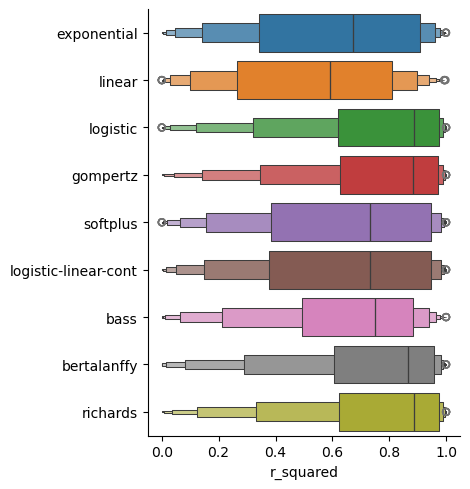

In [35]:
# distribution of r_squared

sns.catplot(y='functional_form', x='r_squared', hue='functional_form',
            data=fit_params[fit_params["r_squared"] > 0], kind='boxen', legend=False)
plt.ylabel('')


if save_fig:
    plt.savefig(f'figures/{sample}_{today}_r_squared_dist.png', **savefig_settings)

In [36]:
fit_params[fit_params["r_squared"] > 0].groupby('functional_form')['r_squared'].mean()

functional_form
bass                    0.656234
bertalanffy             0.736936
exponential             0.603588
gompertz                0.756264
linear                  0.537695
logistic                0.751775
logistic-linear-cont    0.637045
richards                0.753711
softplus                0.640551
Name: r_squared, dtype: float64

In [37]:
fit_params[fit_params["r_squared"] > 0.8].groupby('functional_form')['r_squared'].mean()

functional_form
bass                    0.899580
bertalanffy             0.930197
exponential             0.922591
gompertz                0.940053
linear                  0.893023
logistic                0.940936
logistic-linear-cont    0.939595
richards                0.940909
softplus                0.939208
Name: r_squared, dtype: float64

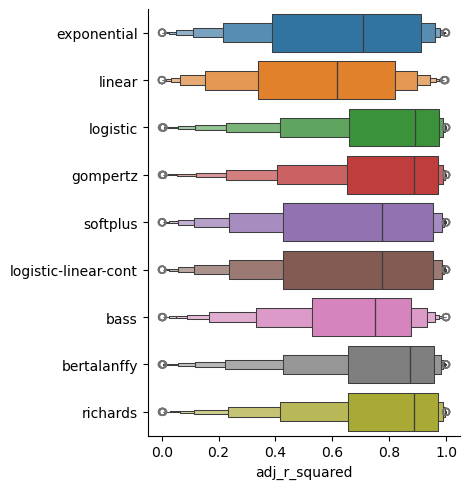

In [38]:
# distribution of adj r sq
sns.catplot(y='functional_form', x='adj_r_squared', hue='functional_form',
            data=fit_params[(fit_params["adj_r_squared"] > 0) & (fit_params["adj_r_squared"] <= 1)],
            kind='boxen', legend=False)
plt.ylabel('')

if save_fig:
    plt.savefig(f'figures/{sample}_{today}_adj_r_squared_dist.png', **savefig_settings)

# Check outliers in r_squared

In [52]:
neg_r2 = fit_params[fit_params['r_squared'] < -1e-10]

In [53]:
neg_r2['technology'].nunique()

1125

In [54]:
neg_r2

,functional_form,fit_procedure,fit_success,r_squared,adj_r_squared,MCp,BIC,MAPE,a,b,...,c_std,infodict,fit_message,int_flat,technology,Technology Name,d,d_std,error_type,error_msg
418,softplus,curve_fit,True,-9.828523e-06,-0.023266,3.596458e+01,3.820811e+01,3.373549,0.000036,3.311584e-06,...,1.456156e-12,"{'nfev': 67, 'fvec': [7.245421457537168, 7.245...",`xtol` termination condition is satisfied.,3.0,Telegraph Traffic_Total Number_BE,Telegraph Traffic,NaN,NaN,NaN,NaN
616,softplus,curve_fit,True,-1.255159e-05,-0.020702,3.011112e+07,3.186181e+07,0.760033,0.008667,6.569405e-07,...,5.616903e-08,"{'nfev': 142, 'fvec': [4720.432426451676, 4482...",`xtol` termination condition is satisfied.,3.0,Beer_Annual Production_AT,Beer Production,NaN,NaN,NaN,NaN
634,softplus,curve_fit,True,-8.136142e-05,-0.020916,2.946172e+01,3.118191e+01,6.247874,0.000021,2.200560e-06,...,4.667712e-13,"{'nfev': 71, 'fvec': [6.212123772750641, 6.112...",`xtol` termination condition is satisfied.,3.0,Gold_Annual Production_NZ,Gold,NaN,NaN,NaN,NaN
636,bass,curve_fit,True,-1.437800e-02,-0.042752,3.027098e+01,3.259735e+01,6.467944,0.002690,4.506343e-08,...,1.129741e+03,"{'nfev': 21, 'fvec': [6.272033523169806, 6.173...",`xtol` termination condition is satisfied.,3.0,Gold_Annual Production_NZ,Gold,1000.000000,4.921043e+06,NaN,NaN
679,softplus,curve_fit,True,-2.461979e-05,-0.024219,3.792854e+01,4.035033e+01,3.344881,0.000018,1.957337e-06,...,4.476521e-13,"{'nfev': 41, 'fvec': [6.395957645096419, 6.395...",`xtol` termination condition is satisfied.,3.0,Telegraph Traffic_Total Number_AT,Telegraph Traffic,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49908,gompertz,curve_fit,True,-1.136684e-10,-0.500000,5.508090e+04,5.820589e+04,0.218827,806.798022,1.439448e-01,...,0.000000e+00,"{'nfev': 21, 'fvec': [-226.20197786510278, -23...",`ftol` termination condition is satisfied.,2.0,Crop Harvester_Total Number_HR,Crop Harvester,NaN,NaN,NaN,NaN
49909,softplus,curve_fit,True,-2.613911e-05,-0.500039,5.508234e+04,5.820742e+04,0.218874,0.001875,1.610118e-06,...,4.611466e-08,"{'nfev': 233, 'fvec': [-226.12264260416998, -2...",`xtol` termination condition is satisfied.,3.0,Crop Harvester_Total Number_HR,Crop Harvester,NaN,NaN,NaN,NaN
49911,bass,curve_fit,True,-1.630243e-09,-0.800000,6.196601e+04,6.613267e+04,0.218832,0.952073,2.845290e+00,...,7.574690e+01,"{'nfev': 19, 'fvec': [-226.1925085368182, -238...",`ftol` termination condition is satisfied.,2.0,Crop Harvester_Total Number_HR,Crop Harvester,1317.266513,0.000000e+00,NaN,NaN
49912,bertalanffy,curve_fit,True,-3.013600e-10,-0.500000,5.508090e+04,5.820589e+04,0.218830,806.803221,1.863413e+00,...,0.000000e+00,"{'nfev': 36, 'fvec': [-226.19677905496678, -23...",`ftol` termination condition is satisfied.,2.0,Crop Harvester_Total Number_HR,Crop Harvester,NaN,NaN,NaN,NaN


# Run curve_fitting on cumulative version of annual time series

In [7]:
test = False

start_time = datetime.now()
# suppress overflow warnings
np.seterr(over='ignore', under='ignore')

all_results = []

if test:
    loop_ids = np.arange(0, 10)
else:
    loop_ids = np.arange(0, len(df.index))

print(f"{start_time} - Start running loop over all timeseries")

for i in loop_ids:

    if df.iloc[i]['Metric'] in ['Annual Production', 'Annual production']:

        sl = df.iloc[i, 9:].transpose().dropna()
        tech_name = sl.name
        technology = df['Technology Name'].iloc[i]
        print(f"{datetime.now() - start_time} - Fitting {i}: {tech_name}")

        years = sl.index.to_numpy(dtype='float')

        if years.min() < 0 or years.max() > 2050:
            print("Warning: Time is not in years:", years)
            continue

        values = sl.to_numpy(dtype='float')
        values = values.cumsum()

        rs = make_curve_fits(years, values, tech_name=tech_name, verbosity=0)
        for r in rs: r['Technology Name'] = technology

        all_results += rs

today = datetime.today().strftime('%Y-%m-%d')

# store fit parameters
fit_params = pd.DataFrame(all_results)
if not test:
    fit_params.to_csv(f"./results/fitting_parameters_cumulated_annual_prod_{today}.csv")

print("Loop run finished.")

2025-03-25 16:52:42.163463 - Start running loop over all timeseries
0:00:00.000843 - Fitting 0: Sugar Output_Annual Production_JM
0:00:00.725156 - Fitting 1: Sugar Output_Annual Production_BB
0:00:01.086700 - Fitting 2: Sugar Output_Annual Production_CU
0:00:01.181636 - Fitting 3: Beer_Annual Production_GB
0:00:01.427433 - Fitting 4: Sugar Output_Annual Production_MU
0:00:01.828740 - Fitting 10: Sugar Output_Annual Production_ID
0:00:01.922307 - Fitting 14: Beer_Annual Production_BE
0:00:02.010405 - Fitting 29: Sugar Output_Annual Production_PH
0:00:02.630112 - Fitting 33: Beer_Annual Production_FR
0:00:02.721289 - Fitting 48: Gold_Annual Production_AU
0:00:03.159063 - Fitting 63: Sugar Output_Annual Production_ZA
0:00:03.419498 - Fitting 64: Zinc_Annual Production_US
0:00:03.503766 - Fitting 65: Crude Petroleum_Annual Production_US
0:00:03.590689 - Fitting 68: Beer_Annual Production_AT
0:00:03.837221 - Fitting 70: Gold_Annual Production_NZ
0:00:04.142382 - Fitting 87: Crude Petroleum_

KeyboardInterrupt: 

In [13]:
fit_params['fit_success'].sum() / len(fit_params)

0.999780737817245

In [14]:
(fit_params['r_squared'] > 0).sum() / len(fit_params)

0.9959984651647207

Text(-96.30555555555556, 0.5, '')

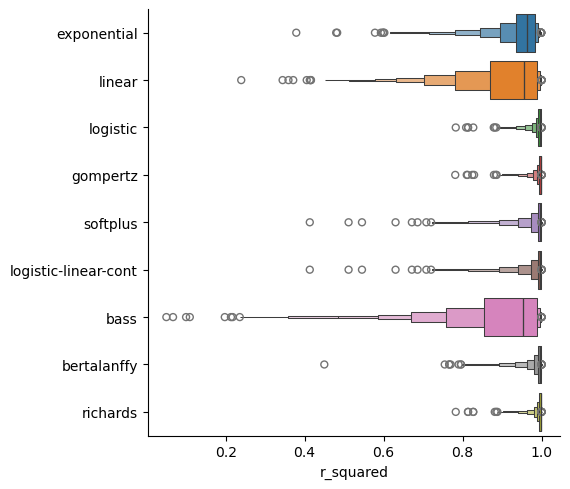

In [28]:
# distribution of r_squared
sns.catplot(y='functional_form', x='r_squared', hue='functional_form',
            data=fit_params[fit_params["r_squared"] > 0], kind='boxen', legend=False, aspect=1.2)
plt.ylabel('')

In [15]:
fit_params['r_squared_masked'] = fit_params['r_squared'].mask(fit_params['r_squared'] < 0).mask(fit_params['r_squared'] > 1)

In [16]:
fit_params.groupby('functional_form')['r_squared_masked'].describe()

,count,mean,std,min,25%,50%,75%,max
functional_form,,,,,,,,
bass,1958.0,0.899896,0.130183,0.049671,0.853028,0.953259,0.989307,0.999921
bertalanffy,2027.0,0.989243,0.026815,0.449756,0.991217,0.997095,0.998874,0.999988
exponential,2027.0,0.945096,0.061945,0.378733,0.936057,0.962832,0.982512,0.999429
gompertz,2027.0,0.993130,0.015709,0.781412,0.994059,0.997431,0.998845,0.999942
linear,2027.0,0.911094,0.109062,0.239321,0.869529,0.955828,0.988699,1.000000
logistic,2027.0,0.991028,0.016012,0.782699,0.991012,0.995126,0.997662,0.999958
logistic-linear-cont,2027.0,0.984190,0.041364,0.412964,0.990019,0.996822,0.998702,1.000000
richards,2023.0,0.993338,0.015466,0.782699,0.994272,0.997512,0.998898,0.999976
softplus,2027.0,0.984359,0.041364,0.412964,0.989954,0.997154,0.998965,1.000000


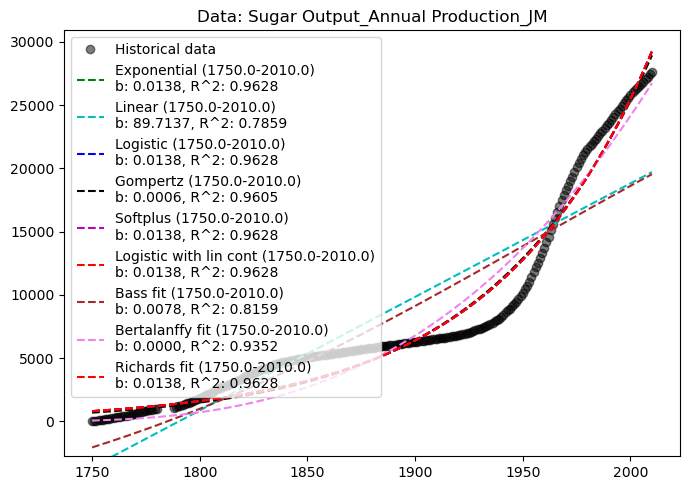

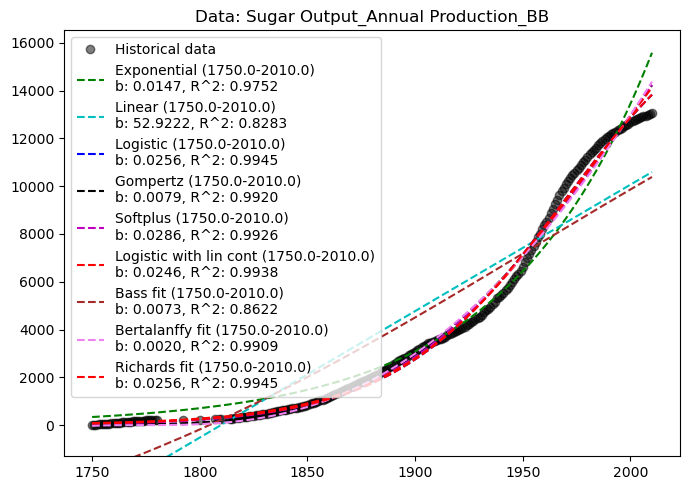

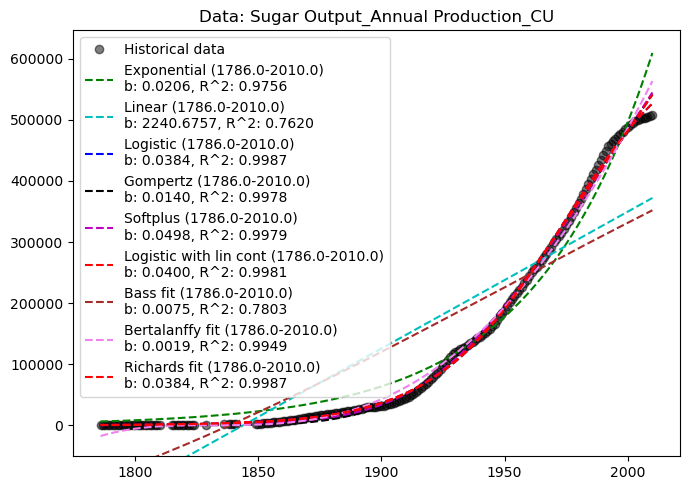

In [33]:
# Plot some examples

for i in [0, 9, 18]:
    tech_name = fit_params.loc[i]['technology']

    sl = df.iloc[df.index == tech_name, 9:].transpose().dropna()
    years = sl.index.to_numpy(dtype='float')
    values = sl.to_numpy(dtype='float').cumsum()
    fig = plot_curve_fits(years, values, fit_params.loc[i:i+8].to_dict('records'), tech_name=fit_params.loc[i]['technology'])

# Run curve fitting only for one functional form

In [8]:
# note: for reponse 'infodict' to be recorded in fitting procedure, set verbosity > 2

test = False

start_time = datetime.now()
# suppress overflow warnings
np.seterr(over='ignore', under='ignore')

all_results = []

if test:
    loop_ids = np.arange(0, 10)
else:
    loop_ids = np.arange(0, len(df.index))

print(f"{start_time} - Start running loop over all timeseries")

for i in loop_ids:
    sl = df.iloc[i, 9:].transpose().dropna()
    tech_name = sl.name
    technology = df['Technology Name'].iloc[i]
    print(f"{datetime.now() - start_time} - Fitting {i}: {tech_name}")

    years = sl.index.to_numpy(dtype='float')

    if years.min() < 0 or years.max() > 2050:
        print("Warning: Time is not in years:", years)
        continue

    values = sl.to_numpy(dtype='float')

    rs = fit_bass(years, values, verbosity=0)
    rs['Technology Name'] = technology
    rs['technology'] = tech_name

    all_results += [rs]

today = datetime.today().strftime('%Y-%m-%d')

# store fit parameters
fit_params_updated = pd.DataFrame(all_results)
if not test:
    fit_params_updated.to_csv(f"./results/fitting_parameters_bass_{today}.csv")

print("Loop run finished.")

2025-03-25 16:53:17.041425 - Start running loop over all timeseries
0:00:00.000956 - Fitting 0: Sugar Output_Annual Production_JM
0:00:00.061755 - Fitting 1: Sugar Output_Annual Production_BB
0:00:00.108214 - Fitting 2: Sugar Output_Annual Production_CU
0:00:00.145324 - Fitting 3: Beer_Annual Production_GB
0:00:00.163019 - Fitting 4: Sugar Output_Annual Production_MU
0:00:00.207197 - Fitting 5: Railroad_Cumulative Length_NO
0:00:00.215499 - Fitting 6: Railroad_Cumulative Length_FR
0:00:00.230137 - Fitting 7: Railroad_Cumulative Length_FI
0:00:00.235799 - Fitting 8: Railroad_Cumulative Length_SE
0:00:00.273104 - Fitting 9: Railroad_Cumulative Length_DK
0:00:00.298429 - Fitting 10: Sugar Output_Annual Production_ID
0:00:00.488808 - Fitting 11: Radio_Total Number_RU
0:00:00.508415 - Fitting 12: Railroad_Cumulative Length_IT
0:00:00.511884 - Fitting 13: Railroad_Cumulative Length_PT
0:00:00.515430 - Fitting 14: Beer_Annual Production_BE
0:00:00.536129 - Fitting 15: Radio_Total Number_SE
0:

/media/Data/Projects/Measuring technology growth/growth-measures/goodness_fit_measures.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
/media/Data/Projects/Measuring technology growth/growth-measures/goodness_fit_measures.py:36: RuntimeWarning: divide by zero encountered in scalar divide
  adj_r_squared = 1 - ((ss_res/(len(xdata)-len(popt)-1)) / (ss_tot/(len(xdata)-1)))


0:00:48.541165 - Fitting 849: Capture Fisheries_Annual production_GD
0:00:48.569407 - Fitting 850: Capture Fisheries_Annual production_GU
0:00:48.619572 - Fitting 851: Capture Fisheries_Annual production_GT
0:00:48.663939 - Fitting 852: Capture Fisheries_Annual production_GN
0:00:48.740328 - Fitting 853: Capture Fisheries_Annual production_GW
0:00:48.800918 - Fitting 854: Capture Fisheries_Annual production_GY
0:00:48.841991 - Fitting 855: Capture Fisheries_Annual production_HT
0:00:48.901984 - Fitting 856: Capture Fisheries_Annual production_PF
0:00:48.939829 - Fitting 857: Capture Fisheries_Annual production_FI
0:00:48.997429 - Fitting 858: Capture Fisheries_Annual production_CW
0:00:49.069735 - Fitting 859: Capture Fisheries_Annual production_FJ
0:00:49.076154 - Fitting 860: Capture Fisheries_Annual production_CY
0:00:49.116636 - Fitting 861: Capture Fisheries_Annual production_CZ
0:00:49.123765 - Fitting 862: Capture Fisheries_Annual production_DK
0:00:49.174811 - Fitting 863: Capt

/media/Data/Projects/Measuring technology growth/growth-measures/goodness_fit_measures.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
/media/Data/Projects/Measuring technology growth/growth-measures/goodness_fit_measures.py:36: RuntimeWarning: divide by zero encountered in scalar divide
  adj_r_squared = 1 - ((ss_res/(len(xdata)-len(popt)-1)) / (ss_tot/(len(xdata)-1)))
/media/Data/Projects/Measuring technology growth/growth-measures/goodness_fit_measures.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
/media/Data/Projects/Measuring technology growth/growth-measures/goodness_fit_measures.py:36: RuntimeWarning: divide by zero encountered in scalar divide
  adj_r_squared = 1 - ((ss_res/(len(xdata)-len(popt)-1)) / (ss_tot/(len(xdata)-1)))


0:00:54.600375 - Fitting 971: Capture Fisheries_Annual production_SG
0:00:54.609592 - Fitting 972: Capture Fisheries_Annual production_SX
0:00:54.623287 - Fitting 973: Capture Fisheries_Annual production_SK
0:00:54.725193 - Fitting 974: Capture Fisheries_Annual production_SI
0:00:54.737063 - Fitting 975: Capture Fisheries_Annual production_SB
0:00:54.771032 - Fitting 976: Capture Fisheries_Annual production_SO
0:00:54.821219 - Fitting 977: Capture Fisheries_Annual production_ZA
0:00:54.828255 - Fitting 978: Capture Fisheries_Annual production_ES
0:00:54.864762 - Fitting 979: Capture Fisheries_Annual production_LK
0:00:55.279343 - Fitting 980: Capture Fisheries_Annual production_KN
0:00:55.355528 - Fitting 981: Capture Fisheries_Annual production_LC
0:00:55.580711 - Fitting 982: Aquaculture Production_Annual production_VE
0:00:55.639692 - Fitting 983: Capture Fisheries_Annual production_UA
0:00:55.649724 - Fitting 984: Capture Fisheries_Annual production_AR
0:00:55.679701 - Fitting 985:

...

0:06:14.253753 - Fitting 5420: Liquid Biofuels_Installed electricity capacity_VU
0:06:14.261131 - Fitting 5421: Solar Photovoltaic_Installed electricity capacity_KW
0:06:14.273456 - Fitting 5422: Copper|Mining_Annual production_TZ
0:06:14.415105 - Fitting 5423: Vinyl Chloride_Annual production_World
0:06:14.543321 - Fitting 5424: Biogas_Installed electricity capacity_SV
0:06:14.549463 - Fitting 5425: PCV3 Vaccine_Share of Population_GY
0:06:14.674350 - Fitting 5426: PCV3 Vaccine_Share of Population_HN
0:06:14.734387 - Fitting 5427: RCV1 Vaccine_Share of Population_CV
0:06:15.452965 - Fitting 5428: Solar Photovoltaic_Installed electricity capacity_AR
0:06:15.463290 - Fitting 5429: Flywheel Battery Storage_Cumulative Rated Power_US
0:06:15.467699 - Fitting 5430: PCV3 Vaccine_Share of Population_HU
0:06:15.487358 - Fitting 5431: Formaldehyde_Annual production_World
0:06:15.912107 - Fitting 5432: PCV3 Vaccine_Share of Population_SL
0:06:15.973242 - Fitting 5433: PCV3 Vaccine_Share of Popul

/media/Data/Projects/Measuring technology growth/growth-measures/goodness_fit_measures.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
/media/Data/Projects/Measuring technology growth/growth-measures/goodness_fit_measures.py:36: RuntimeWarning: divide by zero encountered in scalar divide
  adj_r_squared = 1 - ((ss_res/(len(xdata)-len(popt)-1)) / (ss_tot/(len(xdata)-1)))
/media/Data/Projects/Measuring technology growth/growth-measures/goodness_fit_measures.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
/media/Data/Projects/Measuring technology growth/growth-measures/goodness_fit_measures.py:36: RuntimeWarning: divide by zero encountered in scalar divide
  adj_r_squared = 1 - ((ss_res/(len(xdata)-len(popt)-1)) / (ss_tot/(len(xdata)-1)))


0:06:17.058384 - Fitting 5459: RCV1 Vaccine_Share of Population_BD
0:06:17.076337 - Fitting 5460: BCG Vaccine_Share of Population_AT
0:06:17.082829 - Fitting 5461: Solar Photovoltaic_Installed electricity capacity_CL
0:06:17.358502 - Fitting 5462: RCV1 Vaccine_Share of Population_LA
0:06:17.417695 - Fitting 5463: Salt Production_Annual production_KZ
0:06:17.557332 - Fitting 5464: HIB3 Vaccine_Share of Population_IQ
0:06:17.575089 - Fitting 5465: Offshore Wind Energy_Installed electricity capacity_KR
0:06:17.621295 - Fitting 5466: Biogas_Installed electricity capacity_GP
0:06:17.665670 - Fitting 5467: Raw Steel Production_Annual production_GH
0:06:17.691125 - Fitting 5468: HIB3 Vaccine_Share of Population_BT
0:06:17.695318 - Fitting 5469: Solar Photovoltaic_Installed electricity capacity_GN
0:06:17.771802 - Fitting 5470: HEPBB Vaccine_Share of Population_DJ
0:06:17.778247 - Fitting 5471: Copper|Mining_Annual production_MY
0:06:17.791836 - Fitting 5472: Primary Bauxite Production_Annual 

/media/Data/Projects/Measuring technology growth/growth-measures/goodness_fit_measures.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  r_squared = 1 - (ss_res / ss_tot)
/media/Data/Projects/Measuring technology growth/growth-measures/goodness_fit_measures.py:36: RuntimeWarning: divide by zero encountered in scalar divide
  adj_r_squared = 1 - ((ss_res/(len(xdata)-len(popt)-1)) / (ss_tot/(len(xdata)-1)))


0:06:20.671290 - Fitting 5525: Crop Harvester_Total Number_TM
0:06:20.812062 - Fitting 5526: RCV1 Vaccine_Share of Population_TN
0:06:20.821233 - Fitting 5527: Biogas_Installed electricity capacity_MD
0:06:20.825987 - Fitting 5528: Crop Harvester_Total Number_AZ
0:06:20.833100 - Fitting 5529: Crop Harvester_Total Number_KG
0:06:20.842765 - Fitting 5530: Passenger Cars_Total Number_KG
0:06:20.852165 - Fitting 5531: Marine Energy_Installed electricity capacity_BR
0:06:20.860141 - Fitting 5532: Crop Harvester_Total Number_KZ
0:06:20.868219 - Fitting 5533: Passenger Cars_Total Number_RU
0:06:21.034111 - Fitting 5534: PCV3 Vaccine_Share of Population_ZW
0:06:21.057783 - Fitting 5535: Crop Harvester_Total Number_AM
0:06:21.068844 - Fitting 5536: PCV3 Vaccine_Share of Population_BW
0:06:21.125595 - Fitting 5537: Steam Locomotives_Cumulative Total Capacity_World
0:06:21.160324 - Fitting 5538: Solar Photovoltaic_Installed electricity capacity_LV
0:06:21.210625 - Fitting 5539: Iron Ore_Annual pr

Text(-0.18055555555554825, 0.5, '')

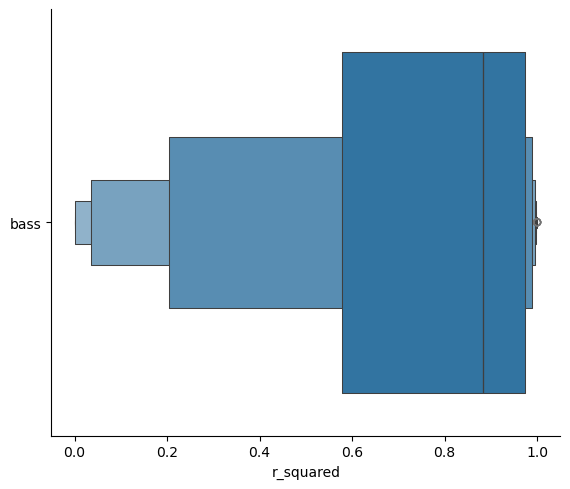

In [14]:
sns.catplot(y='functional_form', x='r_squared', hue='functional_form',
            data=fit_params_updated[fit_params_updated["r_squared"] > 0], kind='boxen', legend=False, aspect=1.2)
plt.ylabel('')

In [15]:
# update latest version with new fit results

# load last complete version
old_complete_res = pd.read_csv('results/fitting_parameters_all_2025-01-31.csv', index_col=0)
print(old_complete_res['technology'].nunique())

5547


In [16]:
if 'error_type' not in fit_params_updated.columns:
    fit_params_updated['error_type'] = np.nan
if 'error_msg' not in fit_params_updated.columns:
    fit_params_updated['error_msg'] = np.nan

In [17]:
# update the entries with the updated functional form

update_ff = 'bass'
combined_res = old_complete_res.copy()

for i in combined_res.index:
    if combined_res.loc[i]['functional_form'] == update_ff:
        #print(combined_res.loc[i]['technology'])
        try:
            combined_res.loc[i] = fit_params_updated[fit_params_updated['technology'] == combined_res.loc[i]['technology']].iloc[0]
        except IndexError:
            print('missing new data for', combined_res.loc[i]['technology'])

In [18]:
# save result

today = datetime.today().strftime('%Y-%m-%d')

if not test:
    combined_res.to_csv(f"./results/fitting_parameters_all_{today}_updated_bass.csv")

Text(-96.30555555555556, 0.5, '')

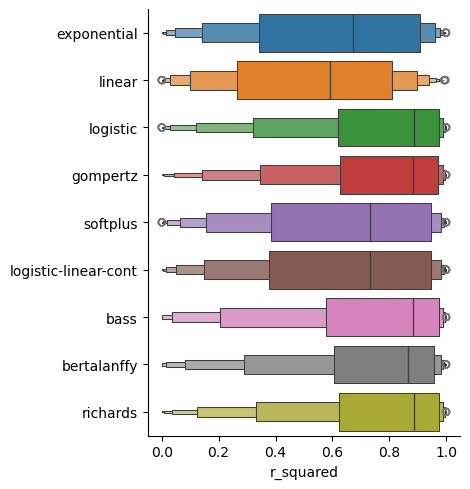

In [20]:
# check distribution of r_squared

sns.catplot(y='functional_form', x='r_squared', hue='functional_form',
            data=combined_res[combined_res["r_squared"] > 0], kind='boxen', legend=False)
plt.ylabel('')